# Step 1 import API

In [20]:
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Step 2 choose your stock

In [21]:

## Import the stock data
TICKERS = ['AAPL', 'MSFT', 'TSLA', 'AMZN', 'BLK']

START_DATE = '2005-01-01'
END_DATE   = '2025-01-01'

## Loading the historical data 
df: pd.DataFrame = YahooDownloader(
                      start_date = START_DATE,
                      end_date = END_DATE,
                      ticker_list = TICKERS

                     ).fetch_data()

print(f"Raw data shape : {df.shape}")
print(df.head())



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (23784, 8)
Raw data shape : (23784, 8)
Price        date      close       high  ...      volume   tic  day
0      2005-01-03   0.947307   0.974548  ...   691992000  AAPL    0
1      2005-01-03   2.226000   2.272000  ...   208930000  AMZN    0
2      2005-01-03  46.149014  47.105122  ...       25900   BLK    0
3      2005-01-03  18.338743  18.482765  ...    65002900  MSFT    0
4      2005-01-04   0.957036   0.979936  ...  1096810400  AAPL    1

[5 rows x 8 columns]


### Note

- fetch_data () : Findata transformer to the pandas data.

# Step 3 Build The Normalzied Plt

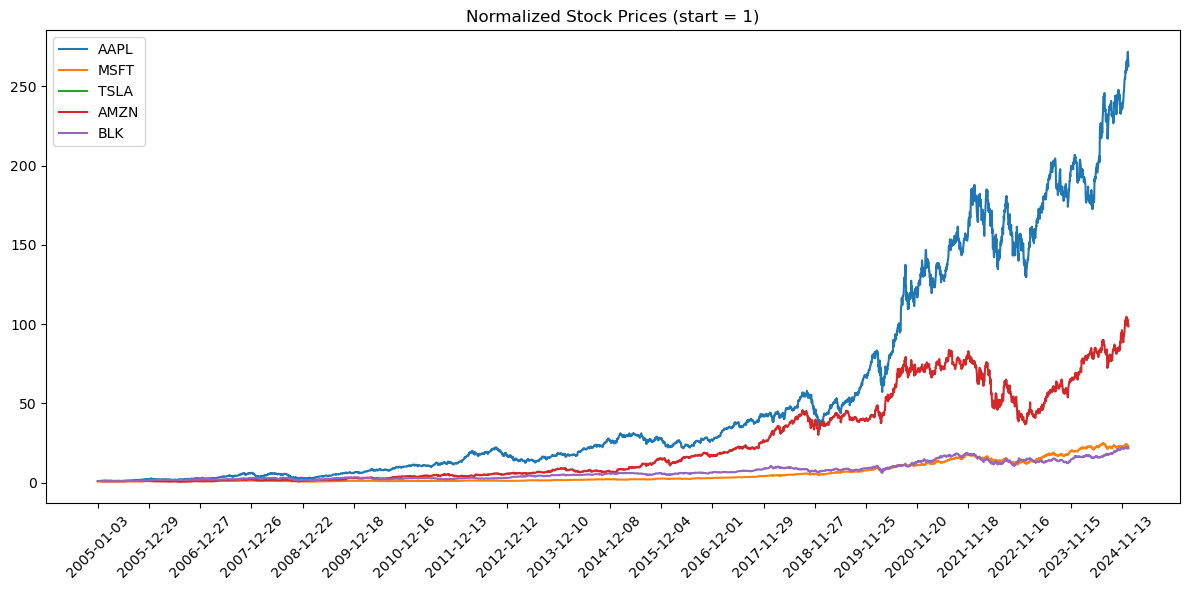

In [ ]:
## The data preprocessing

price_df : pd.DataFrame = df.pivot(index='date', columns='tic', values='close')
price_df = price_df.sort_index()

## Normalized price data
normalized_price_df = price_df / price_df.iloc[0]

# Draw the normalized price data
plt.figure(figsize=(12, 6))

for tic in TICKERS:
    plt.plot(normalized_price_df.index, normalized_price_df[tic], label=tic)

plt.legend()
plt.title('Normalized Stock Prices (start = 1)')

# The data x fillter (only used the 250 days data)
xticks_idx = range(0, len(normalized_price_df.index), 250)
xticks_labels = [normalized_price_df.index[i] for i in xticks_idx]
plt.xticks(xticks_idx, xticks_labels, rotation=45)
plt.tight_layout()
plt.show()